# Assessment Problems

## Problem 1: Data from yfinance

Using the yfinance Python package, write a function called get_data() that downloads all hourly data for the previous five days for the five FAANG stocks:


    Facebook (META)
    Apple (AAPL)
    Amazon (AMZN)
    Netflix (NFLX)
    Google (GOOG)

The function should save the data into a folder called data in the root of your repository using a filename with the format YYYYMMDD-HHmmss.csv where YYYYMMDD is the four-digit year (e.g. 2025), followed by the two-digit month (e.g. 09 for September), followed by the two digit day, and HHmmss is hour, minutes, seconds. Create the data folder if you don't already have one.

## Problem 1. Answer

First step is to import the yfinance python package so we can then access the stock data for the five FAANG stocks and the yfinance functions. Pandas should be included in the yfinance import but I will import anyway. Will also import datetime as it will be required later in the question.

In [3]:

# dates and times
import datetime as dt


# data frame , pulled in with yfinance anyway 
import pandas as pd

# import yahoo finance data
import yfinance as yf

# used in problem 2.
# numerical arrays
import numpy as np

#plotting
import matplotlib.pyplot as plt

Next step is to get the stock data required for for each tickers-Facebook(META),Google(GOOG),Apple(AAPL),Amazon(AMZN)
and Netlix(NFLX).

(A ticker is a shortened name for thhe company stock eg. MSFT for microsoft)

Reference: https://ranaroussi.github.io/yfinance/reference/api/yfinance.download.html

In [4]:
# Example of how to get the data for one ticker
# dat = yf.Ticker("MSFT")

# for multiple tickers , with spaces to seperate each
Tickers = yf.Tickers('META AAPL GOOG AMZN NFLX')


In [5]:
# to download the data 
# use the download function in yfinance, can also test the period function here to check the data
yf.download(['META', 'AAPL', 'GOOG', 'AMZN', 'NFLX'], period='5d')
# info from below link other examples of periods are eg. 1d,5d,1mo,3mo,6mo,1y,2y,5y,
# https://ranaroussi.github.io/yfinance/reference/api/yfinance.download.html

/tmp/ipykernel_11450/2216655638.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  yf.download(['META', 'AAPL', 'GOOG', 'AMZN', 'NFLX'], period='5d')
[**********************60%****                   ]  3 of 5 completedFailed to get ticker 'AMZN' reason: Failed to perform, curl: (28) Connection timed out after 10002 milliseconds. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
[*********************100%***********************]  5 of 5 completed


Price            Close                                                 \
Ticker            AAPL        AMZN        GOOG        META       NFLX   
Date                                                                    
2025-12-15  274.109985  222.539993  309.320007  647.510010  93.769997   
2025-12-16  274.609985  222.559998  307.730011  657.150024  94.570000   
2025-12-17  271.839996  221.270004  298.059998  649.500000  94.790001   
2025-12-18  272.190002  226.759995  303.750000  664.450012  94.000000   
2025-12-19  273.670013  227.350006  308.609985  658.770020  94.389999   

Price             High                                                 ...  \
Ticker            AAPL        AMZN        GOOG        META       NFLX  ...   
Date                                                                   ...   
2025-12-15  280.149994  227.929993  312.700012  653.000000  96.370003  ...   
2025-12-16  275.500000  223.660004  311.845001  662.539978  94.930000  ...   
2025-12-17  276.160004  225.190002  309.195007  661.229980  97.330002  ...   
2025-12-18  273.630005  229.229996  305.260010  670.559998  95.809998  ...   
2025-12-19  274.600006  229.130005  308.989990  671.000000  95.540001  ...   

Price             Open                                                 \
Ticker            AAPL        AMZN        GOOG        META       NFLX   
Date                                                                    
2025-12-15  280.149994  227.929993  312.625000  645.700012  96.019997   
2025-12-16  272.820007  223.039993  306.000000  643.500000  93.879997   
2025-12-17  275.010010  224.660004  309.010010  655.609985  95.980003   
2025-12-18  273.609985  225.710007  303.059998  657.030029  95.019997   
2025-12-19  272.149994  226.759995  303.269989  666.419983  93.570000   

Price          Volume                                          
Ticker           AAPL      AMZN      GOOG      META      NFLX  
Date                                                           
2025-12-15   50409100  47286100  22028900  15549100  40016500  
2025-12-16   37648600  39298900  21285200  14309100  34265000  
2025-12-17   50138700  44034400  29120400  15598500  50472800  
2025-12-18   51630700  50272400  21040500  20260300  37244700  
2025-12-19  144599200  85482700  45205100  49949000  78933200  

[5 rows x 25 columns]

In [6]:
# now to add in the interval required which is every hour 
# interval will be '1h'

# get the data 

df = yf.download(['META', 'AAPL', 'GOOG', 'AMZN', 'NFLX'], period='5d', interval='1h')
# check and see if correct
df



/tmp/ipykernel_11450/2938514840.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(['META', 'AAPL', 'GOOG', 'AMZN', 'NFLX'], period='5d', interval='1h')
[                       0%                       ]

[*********************100%***********************]  5 of 5 completed


Price                           Close                                      \
Ticker                           AAPL        AMZN        GOOG        META   
Datetime                                                                    
2025-12-15 14:30:00+00:00  274.144989  223.029999  307.730011  641.054993   
2025-12-15 15:30:00+00:00  275.510010  224.389999  308.829987  650.545105   
2025-12-15 16:30:00+00:00  274.920013  222.544998  306.142609  650.309998   
2025-12-15 17:30:00+00:00  274.040009  222.375000  307.450012  650.219971   
2025-12-15 18:30:00+00:00  273.369995  223.222595  308.540009  651.219971   
2025-12-15 19:30:00+00:00  273.804993  222.664993  309.364990  650.994995   
2025-12-15 20:30:00+00:00  274.114990  222.550003  309.338989  647.500000   
2025-12-16 14:30:00+00:00  273.170013  222.365005  308.929993  649.309998   
2025-12-16 15:30:00+00:00  272.809998  222.750000  306.359985  650.359985   
2025-12-16 16:30:00+00:00  273.200012  222.309998  305.695007  651.369995   
2025-12-16 17:30:00+00:00  272.130005  221.475800  304.450012  650.265015   
2025-12-16 18:30:00+00:00  273.565002  222.089996  306.089996  655.080017   
2025-12-16 19:30:00+00:00  274.559998  222.649200  307.019989  658.859985   
2025-12-16 20:30:00+00:00  274.470001  222.529999  307.579987  657.159973   
2025-12-17 14:30:00+00:00  275.494995  224.778702  301.010010  659.419983   
2025-12-17 15:30:00+00:00  273.489990  224.139999  300.000000  658.799988   
2025-12-17 16:30:00+00:00  272.869995  223.645004  301.204987  659.469971   
2025-12-17 17:30:00+00:00  273.019989  223.789993  300.750000  657.414978   
2025-12-17 18:30:00+00:00  273.785004  222.914993  298.779999  653.034973   
2025-12-17 19:30:00+00:00  273.650085  222.020004  298.170013  653.580017   
2025-12-17 20:30:00+00:00  271.859985  221.240997  298.049988  649.479980   
2025-12-18 14:30:00+00:00  270.899994  227.582703  302.894806  666.340027   
2025-12-18 15:30:00+00:00  272.299988  228.320007  303.489990  667.030029   
2025-12-18 16:30:00+00:00  270.250000  225.803497  303.605011  663.910400   
2025-12-18 17:30:00+00:00  272.649994  227.044998  305.099487  666.619995   
2025-12-18 18:30:00+00:00  271.369995  226.589996  303.350098  663.940002   
2025-12-18 19:30:00+00:00  271.839996  226.764999  303.869995  664.539978   
2025-12-18 20:30:00+00:00  272.160004  226.759995  303.700012  664.380005   
2025-12-19 14:30:00+00:00  271.734985  226.860001  306.230011  660.469971   
2025-12-19 15:30:00+00:00  271.260803  227.856796  306.920013  666.710022   
2025-12-19 16:30:00+00:00  270.654999  228.410004  306.315002  668.070007   
2025-12-19 17:30:00+00:00  270.750000  228.669006  305.635010  667.549988   
2025-12-19 18:30:00+00:00  271.369995  228.759903  305.755005  667.205017   
2025-12-19 19:30:00+00:00  270.799988  228.649994  305.799988  666.411804   
2025-12-19 20:30:00+00:00  273.670013  227.369995  308.600006  658.789978   

Price                                       High                          \
Ticker                          NFLX        AAPL        AMZN        GOOG   
Datetime                                                                   
2025-12-15 14:30:00+00:00  94.004997  280.049988  227.500000  311.359985   
2025-12-15 15:30:00+00:00  94.430000  275.640411  224.389999  309.390015   
2025-12-15 16:30:00+00:00  94.000000  275.695007  224.500000  308.880005   
2025-12-15 17:30:00+00:00  93.644997  275.100006  223.080002  307.899994   
2025-12-15 18:30:00+00:00  93.959900  274.250000  223.434998  309.369995   
2025-12-15 19:30:00+00:00  93.695000  273.842499  223.410004  309.441010   
2025-12-15 20:30:00+00:00  93.760002  274.720001  222.746506  309.549988   
2025-12-16 14:30:00+00:00  93.949501  274.029999  223.660004  311.845001   
2025-12-16 15:30:00+00:00  94.290100  273.820007  223.479996  309.440002   
2025-12-16 16:30:00+00:00  94.464996  274.279999  223.261597  307.179993   
2025-12-16 17:30:00+00:00  94.258003  273.489990  222.639999  306.619995   
2025-12-1

now that the required data is downloaded we need to save it to a data folder
but first we must format the df to a csv and the name to a date and time required using datetime functions

imported above

reference : https://docs.python.org/3/library/datetime.html
reference : https://www.w3schools.com/python/python_datetime.asp
refernece : https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html


In [7]:
# csv to data folder
# this is how to save the df to a csv file in data folder 

# df.to_csv('data/data.csv')

# but first we must format the date time name as below

In [8]:
## file name and datetime set up 

# below function found on https://docs.python.org/3/library/datetime.html and explained in Ian McLoughlin video lectures.

# now.straftime will output a string 
# ("%Y%m%d %H%M%S") is the format of the string output in (yearmonthdate hourminutesecond)
# can add spaces but neater and shorter like this
# and csv is the extension

# now.strftime("%Y%m%d %H%M%S") + ".csv"


# command (folder + file + extension)
# df.to_csv("data/" + now.strftime("%Y%m%d %H%M%S") + ".csv")

# if above one is run again it will OVERRIGHT the current file in data folder with new information


# change now.strftime function to dt.datetime.now() 
# will save different file each time , with time stamp for name 
df.to_csv("data/" + dt.datetime.now().strftime("%Y%m%d %H%M%S") + ".csv")

## Problem 2: Plotting Data
Write a function called plot_data() that opens the latest data file in the data folder and, on one plot, plots the Close prices for each of the five stocks. The plot should include axis labels, a legend, and the date as a title. The function should save the plot into a plots folder in the root of your repository using a filename in the format YYYYMMDD-HHmmss.png. Create the plots folder if you don't already have one.

## Problem 2. Answer

<Axes: xlabel='Datetime'>

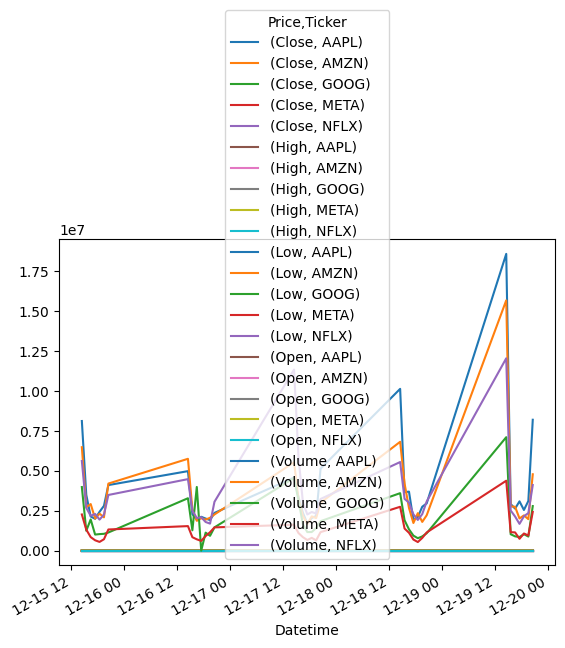

In [9]:
# first check the plot 
df.plot()

In [10]:
# to check the columns, we making sure the close column is there

df.columns

MultiIndex([( 'Close', 'AAPL'),
            ( 'Close', 'AMZN'),
            ( 'Close', 'GOOG'),
            ( 'Close', 'META'),
            ( 'Close', 'NFLX'),
            (  'High', 'AAPL'),
            (  'High', 'AMZN'),
            (  'High', 'GOOG'),
            (  'High', 'META'),
            (  'High', 'NFLX'),
            (   'Low', 'AAPL'),
            (   'Low', 'AMZN'),
            (   'Low', 'GOOG'),
            (   'Low', 'META'),
            (   'Low', 'NFLX'),
            (  'Open', 'AAPL'),
            (  'Open', 'AMZN'),
            (  'Open', 'GOOG'),
            (  'Open', 'META'),
            (  'Open', 'NFLX'),
            ('Volume', 'AAPL'),
            ('Volume', 'AMZN'),
            ('Volume', 'GOOG'),
            ('Volume', 'META'),
            ('Volume', 'NFLX')],
           names=['Price', 'Ticker'])

<Axes: xlabel='Datetime'>

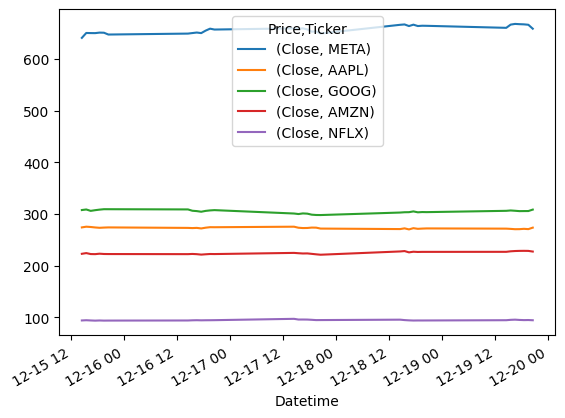

In [11]:
# to get the closing prices for each of the tickers
df[[('Close', 'META'), ('Close', 'AAPL'), ('Close', 'GOOG'), ('Close', 'AMZN'), ('Close', 'NFLX')]].plot()

# [] the square brackets go into the dataframe and find whatever you give it inside thhe brackets

https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html

<Axes: xlabel='Datetime'>

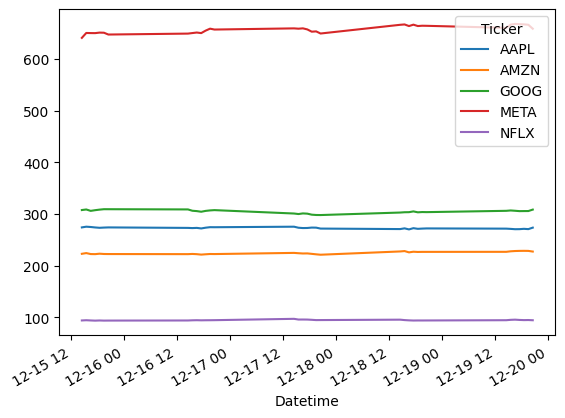

In [12]:
# so to plot all closing prices(better than having to spell them all out)(thanks to pandas we dont have to hardcode them in)
df['Close'].plot()

all information on next part was found from below link and lecturers videos

reference:

https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html


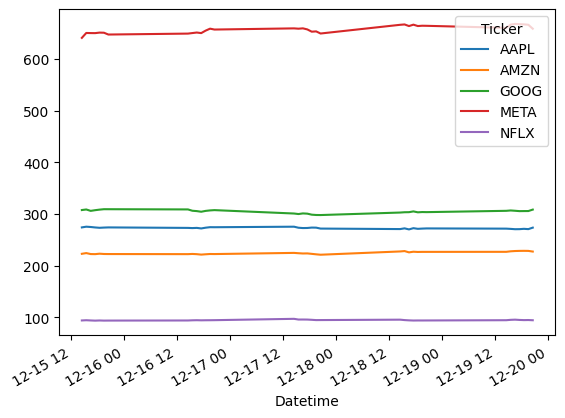

In [13]:
# create new figure and axis
# ax tell what the arguement is and subplot creates a blank plot
fig, ax = plt.subplots()

# plot all closing prices
# insert the arguements
df['Close'].plot(ax=ax)

# current date and time (getting current time stamp)(as used above)
now = dt.datetime.now()

# file name (creating a new filename based on new timestamp)(as used above)(change place(plot) and change type to (png)
filename = "plots/" + dt.datetime.now().strftime("%Y%m%d %H%M%S") + ".png"


# save figure to plots folder
# dpi is the pixels per inch , from lecture found that 300 is suitable amount for it to not look blocky
fig.savefig(filename, dpi=300)

# reference: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html
# shows savefig function and explains how to use it 



references outside the lectures

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html
https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html
dpi- https://github.com/spyder-ide/spyder/issues/22039
more about matplotlib - https://www.w3schools.com/python/matplotlib_plotting.asp




## Problem 3: Script
Create a Python script called faang.py in the root of your repository. Copy the above functions into it and make it so that whenever someone at the terminal types ./faang.py, the script runs, downloading the data and creating the plot. Note that this will require a shebang line and the script to be marked executable. Explain the steps you took in your notebook.

## Problem 3. Answer

#! /usr/bin/env python

# The above shebang should be put on the first line above any imports(must be done like that)
# This put at the top is to say this script should be run in python

# followed by the imports

import datetime as dt

import pandas as pd

import yfinance as yf

import numpy as np

import matplotlib.pyplot as plt

# followed by the downloading of data needed
Tickers = yf.Tickers('META AAPL GOOG AMZN NFLX')

df = yf.download(['META', 'AAPL', 'GOOG', 'AMZN', 'NFLX'], period='5d', interval='1h')

# filename and datetime setup

df.to_csv("data/" + dt.datetime.now().strftime("%Y%m%d %H%M%S") + ".csv")

# plotting the close data
df[[('Close', 'META'), ('Close', 'AAPL'), ('Close', 'GOOG'), ('Close', 'AMZN'), ('Close', 'NFLX')]].plot()

df['Close'].plot()

# create new figure and axis
# ax tell what the arguement is and subplot creates a blank plot
fig, ax = plt.subplots()

# plot all closing prices
# insert the arguements
df['Close'].plot(ax=ax)

# current date and time And changing the place its saved and the pixel size
now = dt.datetime.now()

#filename based on timestamp,change place and type
filename = "plots/" + dt.datetime.now().strftime("%Y%m%d %H%M%S") + ".png"

#save to folder and make the pixels better quality
fig.savefig(filename, dpi=300)


To mark the script executable
chmod +x faang.py is to be input into terminal at bottom to make sure the file can run, this can be checked by ls -l and results should show back 
-rwxrwxrwx  1 codespace codespace   1218 Dec 21 02:24  faang.py
X inbetween the rw instead of – means its working

References:
 lecture video V25 on Script in codespace
https://realpython.com/python-shebang/


## Problem 4: Automation
Create a GitHub Actions workflow to run your script every Saturday morning. The script should be called faang.yml in a .github/workflows/ folder in the root of your repository. In your notebook, explain each of the individual lines in your workflow.

In [14]:
# first will need to get the lists in the folder, and then get the most current list
# Listing files in a folder.
import os

# https://docs.python.org/3/library/os.html
# Video lecture on listing files V.31

In [15]:
# this will locate the data folder and List the files in the data folder.
data_files = os.listdir('data/')

# then to look at them 
data_files

['20251216 000316.csv',
 '20251215 235948.csv',
 '20251215 201643.csv',
 '20251215 214238.csv',
 '20251220 234223.csv',
 '20251221 002019.csv',
 '20251215 180815.csv',
 '20251212 233601.csv',
 '20251215 213224.csv',
 '20251215 235136.csv',
 '20251216 000112.csv',
 '20251215 234253.csv']

In [16]:
# using sort function this will list the data files in order of newest to oldest
sorted(data_files, reverse=True)

['20251221 002019.csv',
 '20251220 234223.csv',
 '20251216 000316.csv',
 '20251216 000112.csv',
 '20251215 235948.csv',
 '20251215 235136.csv',
 '20251215 234253.csv',
 '20251215 214238.csv',
 '20251215 213224.csv',
 '20251215 201643.csv',
 '20251215 180815.csv',
 '20251212 233601.csv']

In [17]:


# file still not in order we want 
data_files



['20251216 000316.csv',
 '20251215 235948.csv',
 '20251215 201643.csv',
 '20251215 214238.csv',
 '20251220 234223.csv',
 '20251221 002019.csv',
 '20251215 180815.csv',
 '20251212 233601.csv',
 '20251215 213224.csv',
 '20251215 235136.csv',
 '20251216 000112.csv',
 '20251215 234253.csv']

In [18]:
#to sort the data file into order we need 
data_files.sort(reverse=True)

# to check it now
data_files

# https://docs.python.org/3/library/stdtypes.html#list.sort

['20251221 002019.csv',
 '20251220 234223.csv',
 '20251216 000316.csv',
 '20251216 000112.csv',
 '20251215 235948.csv',
 '20251215 235136.csv',
 '20251215 234253.csv',
 '20251215 214238.csv',
 '20251215 213224.csv',
 '20251215 201643.csv',
 '20251215 180815.csv',
 '20251212 233601.csv']

In [19]:
# this will show the newest data file
data_files[0]

'20251221 002019.csv'

In [21]:
# to read in the the CSV file and to format the structure correctly , using link below
# to make header out of row 0 and 1,  header=[0, 1],
#datatime seems to be index for this dataframe, index_col function to tidy up ,it is on 0 for this dataframe
df = pd.read_csv(f'data/{data_files[0]}', header=[0, 1], index_col=0, parse_dates=True)

# https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html

# Show.
df

Price                           Close                                      \
Ticker                           AAPL        AMZN        GOOG        META   
Datetime                                                                    
2025-12-15 14:30:00+00:00  274.144989  223.029999  307.730011  641.054993   
2025-12-15 15:30:00+00:00  275.510010  224.389999  308.829987  650.545105   
2025-12-15 16:30:00+00:00  274.920013  222.544998  306.142609  650.309998   
2025-12-15 17:30:00+00:00  274.040009  222.375000  307.450012  650.219971   
2025-12-15 18:30:00+00:00  273.369995  223.222595  308.540009  651.219971   
2025-12-15 19:30:00+00:00  273.804993  222.664993  309.364990  650.994995   
2025-12-15 20:30:00+00:00  274.114990  222.550003  309.338989  647.500000   
2025-12-16 14:30:00+00:00  273.170013  222.365005  308.929993  649.309998   
2025-12-16 15:30:00+00:00  272.809998  222.750000  306.359985  650.359985   
2025-12-16 16:30:00+00:00  273.200012  222.309998  305.695007  651.369995   
2025-12-16 17:30:00+00:00  272.130005  221.475800  304.450012  650.265015   
2025-12-16 18:30:00+00:00  273.565002  222.089996  306.089996  655.080017   
2025-12-16 19:30:00+00:00  274.559998  222.649200  307.019989  658.859985   
2025-12-16 20:30:00+00:00  274.470001  222.529999  307.579987  657.159973   
2025-12-17 14:30:00+00:00  275.494995  224.778702  301.010010  659.419983   
2025-12-17 15:30:00+00:00  273.489990  224.139999  300.000000  658.799988   
2025-12-17 16:30:00+00:00  272.869995  223.645004  301.204987  659.469971   
2025-12-17 17:30:00+00:00  273.019989  223.789993  300.750000  657.414978   
2025-12-17 18:30:00+00:00  273.785004  222.914993  298.779999  653.034973   
2025-12-17 19:30:00+00:00  273.650085  222.020004  298.170013  653.580017   
2025-12-17 20:30:00+00:00  271.859985  221.240997  298.049988  649.479980   
2025-12-18 14:30:00+00:00  270.899994  227.582703  302.894806  666.340027   
2025-12-18 15:30:00+00:00  272.299988  228.320007  303.489990  667.030029   
2025-12-18 16:30:00+00:00  270.250000  225.803497  303.605011  663.910400   
2025-12-18 17:30:00+00:00  272.649994  227.044998  305.099487  666.619995   
2025-12-18 18:30:00+00:00  271.369995  226.589996  303.350098  663.940002   
2025-12-18 19:30:00+00:00  271.839996  226.764999  303.869995  664.539978   
2025-12-18 20:30:00+00:00  272.160004  226.759995  303.700012  664.380005   
2025-12-19 14:30:00+00:00  271.734985  226.860001  306.230011  660.469971   
2025-12-19 15:30:00+00:00  271.260803  227.856796  306.920013  666.710022   
2025-12-19 16:30:00+00:00  270.654999  228.410004  306.315002  668.070007   
2025-12-19 17:30:00+00:00  270.750000  228.669006  305.635010  667.549988   
2025-12-19 18:30:00+00:00  271.369995  228.759903  305.755005  667.205017   
2025-12-19 19:30:00+00:00  270.799988  228.649994  305.799988  666.411804   
2025-12-19 20:30:00+00:00  273.670013  227.369995  308.600006  658.789978   

Price                                       High                          \
Ticker                          NFLX        AAPL        AMZN        GOOG   
Datetime                                                                   
2025-12-15 14:30:00+00:00  94.004997  280.049988  227.500000  311.359985   
2025-12-15 15:30:00+00:00  94.430000  275.640411  224.389999  309.390015   
2025-12-15 16:30:00+00:00  94.000000  275.695007  224.500000  308.880005   
2025-12-15 17:30:00+00:00  93.644997  275.100006  223.080002  307.899994   
2025-12-15 18:30:00+00:00  93.959900  274.250000  223.434998  309.369995   
2025-12-15 19:30:00+00:00  93.695000  273.842499  223.410004  309.441010   
2025-12-15 20:30:00+00:00  93.760002  274.720001  222.746506  309.549988   
2025-12-16 14:30:00+00:00  93.949501  274.029999  223.660004  311.845001   
2025-12-16 15:30:00+00:00  94.290100  273.820007  223.479996  309.440002   
2025-12-16 16:30:00+00:00  94.464996  274.279999  223.261597  307.179993   
2025-12-16 17:30:00+00:00  94.258003  273.489990  222.639999  306.619995   
2025-12-1

## Problem 4: Automation
Create a GitHub Actions workflow to run your script every Saturday morning. The script should be called faang.yml in a .github/workflows/ folder in the root of your repository. In your notebook, explain each of the individual lines in your workflow.